In [40]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

In [41]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data/sample"

SAMPLE_ID = "44b6_0113de3b"

PROCESSED_DIR = (
        DATA_ROOT
        / "processed"
        / "stage_6_processed_dataset"
        / SAMPLE_ID
)

CELLS_DIR = PROCESSED_DIR / "cells"

In [42]:
# ------------------------------------------------------------
# Load tracks
# ------------------------------------------------------------

tracks = pd.read_csv(
    DATA_ROOT
    / "processed"
    / "stage_7_cell_tracking"
    / "tracks.csv"
)

print(f"Loaded {len(tracks):,} track records.")
print(f"Found {tracks['track_id'].nunique():,} tracks.")

tracks.head()

Loaded 4,223 track records.
Found 370 tracks.


,track_id,frame,cell,cell_id,z,y,x,volume,touches_boundary,boundary_faces,...,relative_velocity_x_um_per_frame,relative_velocity_valid,relative_velocity_samples,relative_velocity_error_ema_um,relative_motion_confidence_next_frame,relative_velocity_updated,position_residual_ema_z_um,position_residual_ema_y_um,position_residual_ema_x_um,position_residual_samples
0,0,0,0,1,0.231183,6.354839,52.204301,186.0,True,z_min|y_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
1,1,0,1,2,0.153153,6.815315,71.774775,222.0,True,z_min|y_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
2,2,0,2,3,0.320833,26.012500,65.191667,240.0,True,z_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
3,3,0,3,4,1.074627,62.743555,58.230665,737.0,True,z_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
4,4,0,4,5,0.364431,98.571429,34.836735,343.0,True,z_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0


In [43]:
cell_files = sorted(CELLS_DIR.glob("t*.csv"))

time_frames = [
    pd.read_csv(file)
    for file in cell_files
]

print(f"Loaded {len(time_frames)} timepoints.")

Loaded 20 timepoints.


## Stage 7A — Legacy gap closing temporarily disabled

The previous proximity-only track stitching can incorrectly join an ended track to a nearby new track before merge analysis has a chance to explain the discontinuity.

The function is retained for reference, but `ENABLE_LEGACY_GAP_CLOSING` is set to `False`. The input `tracks` table therefore remains unchanged during this stage.


In [44]:
# ============================================================
# Stage 7A — Legacy gap closing / track stitching
# Temporarily disabled while merge-aware logic is developed.
# ============================================================

ENABLE_LEGACY_GAP_CLOSING = False

MAX_GAP = 2
STITCH_MAX_DISTANCE = 15.0


def stitch_tracks(
    tracks: pd.DataFrame,
    max_gap: int = MAX_GAP,
    max_distance: float = STITCH_MAX_DISTANCE,
) -> pd.DataFrame:
    """Legacy proximity-only fragment stitching.

    This function is retained for comparison, but it is not called while
    ENABLE_LEGACY_GAP_CLOSING is False.
    """

    tracks = tracks.copy()
    last_frame = int(tracks["frame"].max())

    ends = (
        tracks.sort_values("frame")
        .groupby("track_id")
        .tail(1)
        .set_index("track_id")
    )
    starts = (
        tracks.sort_values("frame")
        .groupby("track_id")
        .head(1)
        .set_index("track_id")
    )

    candidate_parents = ends[ends["frame"] < last_frame]
    candidate_children = starts[starts["frame"] > 0]

    merges: dict[int, int] = {}

    for parent_id, parent_row in candidate_parents.sort_values("frame").iterrows():
        window = candidate_children[
            (candidate_children["frame"] > parent_row["frame"])
            & (
                candidate_children["frame"]
                <= parent_row["frame"] + max_gap
            )
            & (candidate_children.index != parent_id)
        ]

        if window.empty:
            continue

        distance = np.sqrt(
            (window["z"] - parent_row["z"]) ** 2
            + (window["y"] - parent_row["y"]) ** 2
            + (window["x"] - parent_row["x"]) ** 2
        )

        candidates = distance[distance <= max_distance]

        if candidates.empty:
            continue

        best_child = int(candidates.idxmin())

        if best_child in merges:
            continue

        merges[best_child] = int(parent_id)

    def resolve(track_id: int) -> int:
        seen: set[int] = set()

        while track_id in merges and track_id not in seen:
            seen.add(track_id)
            track_id = merges[track_id]

        return track_id

    tracks["track_id"] = tracks["track_id"].map(resolve)

    print(
        f"Legacy stitcher joined {len(merges)} fragment(s) "
        f"with a gap of at most {max_gap} frame(s)."
    )

    return tracks


tracks_before_stitching = tracks.copy()

if ENABLE_LEGACY_GAP_CLOSING:
    tracks = stitch_tracks(tracks)
else:
    print("Legacy proximity-only track stitching is disabled.")
    print("The original Stage 8 track IDs are preserved.")


Legacy proximity-only track stitching is disabled.
The original Stage 8 track IDs are preserved.


## Stage 7B — Merge-aware many-to-one event detection

This stage searches for the temporal signature:

```text
two detections at frame t
        ↓
one detection at frame t + 1
```

The merged detection may inherit one of the parent track IDs, so the detector does **not** require both parent tracks to end or the merged object to start a new track.

A candidate is scored using:

- constant-velocity predicted parent positions;
- distance of both predictions from the merged detection;
- combined-volume conservation;
- integrated-intensity conservation, when available;
- agreement between the observed merged centroid and the parents' volume-weighted predicted centroid;
- whether the merged bounding box covers both predicted centers;
- track-discontinuity structure.

No track IDs are changed here. The output is a set of merge hypotheses and track-guided spatial priors for local re-segmentation.


In [45]:
from itertools import combinations


# ------------------------------------------------------------
# Physical calibration and merge-detector parameters
# ------------------------------------------------------------

VOXEL_SIZE_ZYX = np.asarray(
    [1.625, 0.40625, 0.40625],
    dtype=float,
)

MERGE_SEARCH_RADIUS_UM = 12.0
MERGE_POSITION_SCALE_UM = 7.0
MERGE_CENTROID_SCALE_UM = 4.0

MERGE_MAX_VOLUME_REL_ERROR = 0.50
MERGE_MAX_INTENSITY_SUM_REL_ERROR = 0.75
MERGE_MIN_SCORE = 0.60

MERGE_BBOX_MARGIN_ZYX = np.asarray(
    [1.0, 3.0, 3.0],
    dtype=float,
)


# ------------------------------------------------------------
# Add per-detection features to the track records
# ------------------------------------------------------------

OPTIONAL_DETECTION_FEATURES = [
    "cell_id",
    "intensity_sum",
    "intensity_mean",
    "intensity_std",
    "equivalent_radius",
    "axis_major",
    "axis_middle",
    "axis_minor",
    "elongation",
    "flatness",
    "anisotropy",
    "solidity",
    "compactness",
    "bbox_depth",
    "bbox_height",
    "bbox_width",
    "z_min",
    "y_min",
    "x_min",
    "z_max",
    "y_max",
    "x_max",
]


def enrich_tracks_with_detection_features(
    tracks: pd.DataFrame,
    time_frames: list[pd.DataFrame],
) -> pd.DataFrame:
    """Attach feature rows using each track record's frame and cell index."""

    enriched = tracks.copy()

    values: dict[str, list[object]] = {
        column: []
        for column in OPTIONAL_DETECTION_FEATURES
    }

    for track_row in enriched.itertuples(index=False):
        frame = int(track_row.frame)
        cell_index = int(track_row.cell)
        detection = time_frames[frame].iloc[cell_index]

        for column in OPTIONAL_DETECTION_FEATURES:
            values[column].append(
                detection[column]
                if column in detection.index
                else np.nan
            )

    for column, column_values in values.items():
        enriched[column] = column_values

    if "cell_id" not in enriched or enriched["cell_id"].isna().all():
        enriched["cell_id"] = enriched["cell"].astype(int)

    return enriched


track_features = enrich_tracks_with_detection_features(
    tracks,
    time_frames,
)

print(
    f"Prepared {len(track_features):,} track records "
    "with their detection-level features."
)


Prepared 4,223 track records with their detection-level features.


In [46]:
# ------------------------------------------------------------
# Merge-event scoring helpers
# ------------------------------------------------------------

def physical_distance(
    point_a_zyx: np.ndarray,
    point_b_zyx: np.ndarray,
) -> float:
    delta = (
        np.asarray(point_a_zyx, dtype=float)
        - np.asarray(point_b_zyx, dtype=float)
    )

    return float(
        np.linalg.norm(delta * VOXEL_SIZE_ZYX)
    )


def relative_error(
    actual: float,
    expected: float,
) -> float:
    if not np.isfinite(actual) or not np.isfinite(expected):
        return np.nan

    if expected <= 0:
        return np.nan

    return float(abs(actual - expected) / expected)


def exponential_score(
    error: float,
    scale: float,
) -> float:
    if not np.isfinite(error):
        return np.nan

    return float(np.exp(-error / max(scale, 1e-12)))


def predict_track_position(
    track_table: pd.DataFrame,
    track_id: int,
    source_frame: int,
    target_frame: int,
) -> np.ndarray:
    """Predict a track position using its last observed velocity."""

    history = (
        track_table[
            (track_table["track_id"] == track_id)
            & (track_table["frame"] <= source_frame)
        ]
        .sort_values("frame")
    )

    if history.empty:
        raise KeyError(
            f"No history found for track {track_id} "
            f"up to frame {source_frame}."
        )

    last = history.iloc[-1]
    last_position = last[["z", "y", "x"]].to_numpy(dtype=float)

    velocity = np.zeros(3, dtype=float)

    if len(history) >= 2:
        previous = history.iloc[-2]
        frame_delta = float(last["frame"] - previous["frame"])

        if frame_delta > 0:
            previous_position = previous[
                ["z", "y", "x"]
            ].to_numpy(dtype=float)

            velocity = (
                last_position - previous_position
            ) / frame_delta

    prediction_horizon = float(target_frame - last["frame"])

    return last_position + velocity * prediction_horizon


def point_inside_expanded_bbox(
    point_zyx: np.ndarray,
    detection: pd.Series,
    margin_zyx: np.ndarray = MERGE_BBOX_MARGIN_ZYX,
) -> bool | None:
    required = [
        "z_min", "y_min", "x_min",
        "z_max", "y_max", "x_max",
    ]

    if any(
        column not in detection.index
        or not np.isfinite(detection[column])
        for column in required
    ):
        return None

    start = detection[
        ["z_min", "y_min", "x_min"]
    ].to_numpy(dtype=float) - margin_zyx

    stop = detection[
        ["z_max", "y_max", "x_max"]
    ].to_numpy(dtype=float) + margin_zyx

    point = np.asarray(point_zyx, dtype=float)

    return bool(
        np.all(point >= start)
        and np.all(point <= stop)
    )


def weighted_score(
    components: dict[str, float],
    weights: dict[str, float],
) -> float:
    numerator = 0.0
    denominator = 0.0

    for name, value in components.items():
        if np.isfinite(value):
            weight = weights[name]
            numerator += weight * value
            denominator += weight

    return (
        float(numerator / denominator)
        if denominator > 0
        else 0.0
    )


def score_merge_pair(
    parent_a: pd.Series,
    parent_b: pd.Series,
    merged: pd.Series,
    predicted_a_zyx: np.ndarray,
    predicted_b_zyx: np.ndarray,
) -> dict[str, float] | None:
    merged_position = merged[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    distance_a_um = physical_distance(
        predicted_a_zyx,
        merged_position,
    )
    distance_b_um = physical_distance(
        predicted_b_zyx,
        merged_position,
    )

    if max(distance_a_um, distance_b_um) > MERGE_SEARCH_RADIUS_UM:
        return None

    volume_a = float(parent_a["volume"])
    volume_b = float(parent_b["volume"])
    merged_volume = float(merged["volume"])
    expected_volume = volume_a + volume_b

    volume_error = relative_error(
        merged_volume,
        expected_volume,
    )

    if (
        np.isfinite(volume_error)
        and volume_error > MERGE_MAX_VOLUME_REL_ERROR
    ):
        return None

    expected_centroid = (
        volume_a * predicted_a_zyx
        + volume_b * predicted_b_zyx
    ) / max(expected_volume, 1e-12)

    centroid_error_um = physical_distance(
        merged_position,
        expected_centroid,
    )

    intensity_a = float(parent_a.get("intensity_sum", np.nan))
    intensity_b = float(parent_b.get("intensity_sum", np.nan))
    merged_intensity = float(merged.get("intensity_sum", np.nan))

    expected_intensity = intensity_a + intensity_b
    intensity_error = relative_error(
        merged_intensity,
        expected_intensity,
    )

    # Integrated intensity is supportive rather than a strict requirement.
    # Very large disagreement is rejected only when all three values exist.
    if (
        np.isfinite(intensity_error)
        and intensity_error > MERGE_MAX_INTENSITY_SUM_REL_ERROR
    ):
        return None

    bbox_a = point_inside_expanded_bbox(
        predicted_a_zyx,
        merged,
    )
    bbox_b = point_inside_expanded_bbox(
        predicted_b_zyx,
        merged,
    )

    bbox_values = [
        float(value)
        for value in [bbox_a, bbox_b]
        if value is not None
    ]

    bbox_score = (
        float(np.mean(bbox_values))
        if bbox_values
        else np.nan
    )

    parent_distance_score = exponential_score(
        0.5 * (distance_a_um + distance_b_um),
        MERGE_POSITION_SCALE_UM,
    )

    centroid_score = exponential_score(
        centroid_error_um,
        MERGE_CENTROID_SCALE_UM,
    )

    volume_score = exponential_score(
        volume_error,
        0.25,
    )

    intensity_score = exponential_score(
        intensity_error,
        0.35,
    )

    # Shape is recorded as supporting evidence only.
    parent_major = np.nanmax([
        float(parent_a.get("axis_major", np.nan)),
        float(parent_b.get("axis_major", np.nan)),
    ])
    merged_major = float(
        merged.get("axis_major", np.nan)
    )

    axis_major_ratio = (
        merged_major / parent_major
        if np.isfinite(parent_major)
        and parent_major > 0
        and np.isfinite(merged_major)
        else np.nan
    )

    components = {
        "parent_distance": parent_distance_score,
        "centroid": centroid_score,
        "volume": volume_score,
        "intensity": intensity_score,
        "bbox": bbox_score,
    }

    weights = {
        "parent_distance": 0.25,
        "centroid": 0.20,
        "volume": 0.30,
        "intensity": 0.15,
        "bbox": 0.10,
    }

    score = weighted_score(
        components,
        weights,
    )

    return {
        "score": score,
        "distance_a_um": distance_a_um,
        "distance_b_um": distance_b_um,
        "centroid_error_um": centroid_error_um,
        "volume_error": volume_error,
        "intensity_sum_error": intensity_error,
        "bbox_score": bbox_score,
        "axis_major_ratio": axis_major_ratio,
    }


# ------------------------------------------------------------
# Search for 2 -> 1 temporal merge hypotheses
# ------------------------------------------------------------

# Cache repeated track-position predictions.
prediction_cache: dict[tuple[int, int, int], np.ndarray] = {}


def cached_predict_track_position(
        track_id: int,
        source_frame: int,
        target_frame: int,
) -> np.ndarray:
    key = (
        int(track_id),
        int(source_frame),
        int(target_frame),
    )

    if key not in prediction_cache:
        prediction_cache[key] = predict_track_position(
            track_features,
            track_id=int(track_id),
            source_frame=int(source_frame),
            target_frame=int(target_frame),
        )

    return prediction_cache[key]

candidate_records: list[dict[str, object]] = []

frames = sorted(
    int(frame)
    for frame in track_features["frame"].unique()
)

for frame in frames[:-1]:
    merged_frame = frame + 1

    previous = track_features[
        track_features["frame"] == frame
    ].copy()

    current = track_features[
        track_features["frame"] == merged_frame
    ].copy()

    previous_track_ids = set(
        previous["track_id"].astype(int)
    )
    current_track_ids = set(
        current["track_id"].astype(int)
    )

    ended_track_ids = (
        previous_track_ids - current_track_ids
    )

    for _, merged in current.iterrows():
        merged_track_id = int(
            merged["track_id"]
        )

        merged_position = merged[
            ["z", "y", "x"]
        ].to_numpy(dtype=float)

        nearby_parents: list[tuple[int, np.ndarray, float]] = []

        for parent_index, parent in previous.iterrows():
            parent_track_id = int(
                parent["track_id"]
            )

            predicted_position = cached_predict_track_position(
                track_id=parent_track_id,
                source_frame=frame,
                target_frame=merged_frame,
            )

            distance_um = physical_distance(
                predicted_position,
                merged_position,
            )

            if distance_um <= MERGE_SEARCH_RADIUS_UM:
                nearby_parents.append(
                    (
                        parent_index,
                        predicted_position,
                        distance_um,
                    )
                )

        if len(nearby_parents) < 2:
            continue

        prediction_by_index = {
            parent_index: prediction
            for parent_index, prediction, _ in nearby_parents
        }

        nearby_indices = [
            parent_index
            for parent_index, _, _ in nearby_parents
        ]

        for index_a, index_b in combinations(
            nearby_indices,
            2,
        ):
            parent_a = previous.loc[index_a]
            parent_b = previous.loc[index_b]

            track_a = int(parent_a["track_id"])
            track_b = int(parent_b["track_id"])
            pair_track_ids = {track_a, track_b}

            # A parent that has its own different detection at the current
            # frame cannot also be part of this merged detection.
            parent_continues_elsewhere = any(
                parent_id in current_track_ids
                and parent_id != merged_track_id
                for parent_id in pair_track_ids
            )

            if parent_continues_elsewhere:
                continue

            # When the merged detection inherited an old track ID, that ID
            # must belong to one of the two proposed parents.
            if (
                merged_track_id in previous_track_ids
                and merged_track_id not in pair_track_ids
            ):
                continue

            ended_parents = (
                pair_track_ids & ended_track_ids
            )

            if not ended_parents:
                continue

            result = score_merge_pair(
                parent_a,
                parent_b,
                merged,
                prediction_by_index[index_a],
                prediction_by_index[index_b],
            )

            if result is None:
                continue

            if result["score"] < MERGE_MIN_SCORE:
                continue

            merged_detection = time_frames[
                merged_frame
            ].iloc[int(merged["cell"])]

            candidate_records.append({
                "type": "merge",
                "status": "hypothesis",
                "frame": frame,
                "merged_frame": merged_frame,
                "track_a": track_a,
                "track_b": track_b,
                "merged_track": merged_track_id,
                "track_a_ended": track_a in ended_track_ids,
                "track_b_ended": track_b in ended_track_ids,
                "merged_track_started": (
                    merged_track_id not in previous_track_ids
                ),
                "cell_a": int(parent_a["cell"]),
                "cell_b": int(parent_b["cell"]),
                "merged_cell": int(merged["cell"]),
                "cell_id_a": int(parent_a["cell_id"]),
                "cell_id_b": int(parent_b["cell_id"]),
                "merged_cell_id": int(
                    merged_detection.get(
                        "cell_id",
                        merged["cell"],
                    )
                ),
                "predicted_a_z": float(
                    prediction_by_index[index_a][0]
                ),
                "predicted_a_y": float(
                    prediction_by_index[index_a][1]
                ),
                "predicted_a_x": float(
                    prediction_by_index[index_a][2]
                ),
                "predicted_b_z": float(
                    prediction_by_index[index_b][0]
                ),
                "predicted_b_y": float(
                    prediction_by_index[index_b][1]
                ),
                "predicted_b_x": float(
                    prediction_by_index[index_b][2]
                ),
                "volume_a": float(parent_a["volume"]),
                "volume_b": float(parent_b["volume"]),
                "merged_volume": float(merged["volume"]),
                "intensity_sum_a": float(
                    parent_a.get("intensity_sum", np.nan)
                ),
                "intensity_sum_b": float(
                    parent_b.get("intensity_sum", np.nan)
                ),
                "merged_intensity_sum": float(
                    merged.get("intensity_sum", np.nan)
                ),
                **result,
            })


candidate_events = pd.DataFrame(
    candidate_records
)

# ------------------------------------------------------------
# Keep a non-conflicting, high-confidence set of events
# ------------------------------------------------------------

event_columns = [
    "event_id",
    "type",
    "status",
    "frame",
    "merged_frame",
    "track_a",
    "track_b",
    "merged_track",
    "track_a_ended",
    "track_b_ended",
    "merged_track_started",
    "cell_a",
    "cell_b",
    "merged_cell",
    "cell_id_a",
    "cell_id_b",
    "merged_cell_id",
    "predicted_a_z",
    "predicted_a_y",
    "predicted_a_x",
    "predicted_b_z",
    "predicted_b_y",
    "predicted_b_x",
    "volume_a",
    "volume_b",
    "merged_volume",
    "intensity_sum_a",
    "intensity_sum_b",
    "merged_intensity_sum",
    "score",
    "distance_a_um",
    "distance_b_um",
    "centroid_error_um",
    "volume_error",
    "intensity_sum_error",
    "bbox_score",
    "axis_major_ratio",
]

accepted_records: list[dict[str, object]] = []

if not candidate_events.empty:
    claimed_by_frame: dict[int, set[int]] = {}

    for _, candidate in candidate_events.sort_values(
        "score",
        ascending=False,
    ).iterrows():
        merged_frame = int(
            candidate["merged_frame"]
        )

        claimed_tracks = claimed_by_frame.setdefault(
            merged_frame,
            set(),
        )

        pair = {
            int(candidate["track_a"]),
            int(candidate["track_b"]),
        }

        if pair & claimed_tracks:
            continue

        accepted_records.append(
            candidate.to_dict()
        )

        claimed_tracks |= pair

segmentation_events = pd.DataFrame(
    accepted_records
)

if segmentation_events.empty:
    segmentation_events = pd.DataFrame(
        columns=event_columns
    )
else:
    segmentation_events = (
        segmentation_events
        .sort_values(
            ["merged_frame", "score"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    segmentation_events.insert(
        0,
        "event_id",
        np.arange(
            len(segmentation_events),
            dtype=int,
        ),
    )

    segmentation_events = segmentation_events[
        event_columns
    ]

print(
    f"Flagged {len(segmentation_events)} "
    "merge hypothesis/hypotheses."
)

display_columns = [
    "event_id",
    "frame",
    "merged_frame",
    "track_a",
    "track_b",
    "merged_track",
    "merged_cell_id",
    "score",
    "volume_error",
    "intensity_sum_error",
    "centroid_error_um",
]

segmentation_events[
    display_columns
].head(20)


Flagged 92 merge hypothesis/hypotheses.


,event_id,frame,merged_frame,track_a,track_b,merged_track,merged_cell_id,score,volume_error,intensity_sum_error,centroid_error_um
0,0,0,1,73,77,73,78,0.676798,0.055482,0.008340,1.656445
1,1,0,1,2,12,2,3,0.649314,0.195244,0.315342,0.471905
2,2,1,2,147,154,147,153,0.809047,0.011573,0.015157,1.834340
3,3,1,2,46,64,46,58,0.762142,0.028883,0.002306,1.281331
4,4,1,2,31,41,31,39,0.694475,0.038504,0.062503,2.611571
5,5,1,2,179,193,179,185,0.687675,0.064070,0.114044,1.953621
6,6,1,2,185,194,185,189,0.678392,0.062674,0.069251,0.731536
7,7,1,2,59,67,59,74,0.636034,0.017143,0.064691,4.322665
8,8,1,2,142,157,157,158,0.611952,0.127273,0.101284,1.673539
9,9,1,2,40,214,40,55,0.610102,0.108696,0.149390,0.755588


## Stage 7B.1 — Track-guided identity links and spherical seed priors

A high-confidence merge hypothesis does not immediately rewrite the tracks. Instead, both parent identities are linked to the same merged detection with status `pending_local_resegmentation`.

For each parent, the table stores:

- the predicted current center;
- the previous cell volume;
- an equivalent physical radius derived from volume;
- a conservative interior seed radius.

These priors can be passed to a later local 3D re-segmentation stage. Only after that stage produces two valid child detections should track IDs be rewritten.


In [47]:
# ------------------------------------------------------------
# Build merge-aware identity links and seed priors
# ------------------------------------------------------------

VOXEL_VOLUME_UM3 = float(
    np.prod(VOXEL_SIZE_ZYX)
)

SEED_RADIUS_FRACTION = 0.35
MINIMUM_SEED_RADIUS_UM = 0.8


def equivalent_radius_um(
    volume_voxels: float,
) -> float:
    volume_um3 = (
        float(volume_voxels)
        * VOXEL_VOLUME_UM3
    )

    return float(
        (
            3.0 * volume_um3
            / (4.0 * np.pi)
        ) ** (1.0 / 3.0)
    )


seed_records: list[dict[str, object]] = []
link_records: list[dict[str, object]] = []

for _, event in segmentation_events.iterrows():
    event_id = int(event["event_id"])

    for role in ["a", "b"]:
        parent_track_id = int(
            event[f"track_{role}"]
        )

        parent_volume = float(
            event[f"volume_{role}"]
        )

        radius_um = equivalent_radius_um(
            parent_volume
        )

        seed_radius_um = max(
            MINIMUM_SEED_RADIUS_UM,
            SEED_RADIUS_FRACTION * radius_um,
        )

        predicted_center = {
            "z": float(event[f"predicted_{role}_z"]),
            "y": float(event[f"predicted_{role}_y"]),
            "x": float(event[f"predicted_{role}_x"]),
        }

        seed_records.append({
            "event_id": event_id,
            "role": role.upper(),
            "parent_track_id": parent_track_id,
            "merged_track_id": int(
                event["merged_track"]
            ),
            "parent_frame": int(
                event["frame"]
            ),
            "merged_frame": int(
                event["merged_frame"]
            ),
            "predicted_z": predicted_center["z"],
            "predicted_y": predicted_center["y"],
            "predicted_x": predicted_center["x"],
            "parent_volume_voxels": parent_volume,
            "equivalent_radius_um": radius_um,
            "seed_radius_um": seed_radius_um,
        })

        link_records.append({
            "event_id": event_id,
            "parent_track_id": parent_track_id,
            "merged_track_id": int(
                event["merged_track"]
            ),
            "parent_frame": int(
                event["frame"]
            ),
            "merged_frame": int(
                event["merged_frame"]
            ),
            "link_status": "pending_local_resegmentation",
        })


merge_seed_priors = pd.DataFrame(
    seed_records,
    columns=[
        "event_id",
        "role",
        "parent_track_id",
        "merged_track_id",
        "parent_frame",
        "merged_frame",
        "predicted_z",
        "predicted_y",
        "predicted_x",
        "parent_volume_voxels",
        "equivalent_radius_um",
        "seed_radius_um",
    ],
)

merge_track_links = pd.DataFrame(
    link_records,
    columns=[
        "event_id",
        "parent_track_id",
        "merged_track_id",
        "parent_frame",
        "merged_frame",
        "link_status",
    ],
)

print(
    f"Created {len(merge_seed_priors)} "
    "track-guided seed prior(s)."
)
print(
    f"Created {len(merge_track_links)} "
    "pending merge-aware track link(s)."
)

merge_seed_priors.head(10)


Created 184 track-guided seed prior(s).
Created 184 pending merge-aware track link(s).


,event_id,role,parent_track_id,merged_track_id,parent_frame,merged_frame,predicted_z,predicted_y,predicted_x,parent_volume_voxels,equivalent_radius_um,seed_radius_um
0,0,A,73,73,0,1,24.483434,226.823795,135.861446,664.0,3.490116,1.221541
1,0,B,77,73,0,1,25.161290,254.118280,136.096774,93.0,1.812501,0.800000
2,1,A,2,2,0,1,0.320833,26.012500,65.191667,240.0,2.486113,0.870140
3,1,B,12,2,0,1,1.788909,35.497317,70.622540,559.0,3.295498,1.153424
4,2,A,147,147,1,2,47.974624,246.563771,186.884600,1059.0,4.077705,1.427197
5,2,B,154,147,1,2,50.712956,242.161955,176.519095,842.0,3.777645,1.322176
6,3,A,46,46,1,2,14.888779,222.340956,71.626386,1222.0,4.277016,1.496956
7,3,B,64,46,1,2,22.373414,214.049039,75.708169,613.0,3.398370,1.189429
8,4,A,31,31,1,2,8.112787,42.835130,80.544664,1130.0,4.166870,1.458405
9,4,B,41,31,1,2,14.614826,40.079942,91.816860,688.0,3.531669,1.236084


## Stage 7C — Track termination classification

For every track that ends, explain why.

In [48]:
# ============================================================
# Stage 7C — Track termination classification
# ============================================================
# For every track that ends, explain why, checking these in priority
# order (first match wins):
#
#   reached_last_frame            movie simply ended
#   left_imaging_volume           last detection touches the FOV edge
#   merge_event                   flagged in Stage 7B segmentation_events
#   possible_division             2 daughters appear nearby, volumes ~sum
#   fragmented_likely_continuation a near-miss stitch (just outside
#                                  Stage 7A's stricter thresholds)
#   segmentation_failure          last-frame volume is an outlier vs.
#                                  the track's own history
#   unknown                       none of the above

FOV_EDGE_MARGIN = 5.0

DIVISION_MAX_GAP = 2
DIVISION_MAX_DISTANCE = 20.0
DIVISION_VOLUME_TOLERANCE = 0.3

FRAGMENT_MAX_GAP = 4
FRAGMENT_MAX_DISTANCE = 25.0
FRAGMENT_MAX_VOLUME_RATIO = 2.0

SEG_FAILURE_VOLUME_RATIO = 1.6  # last-frame volume vs. track's own median

# ---- Global imaging-volume bounds, estimated from all detections ----
all_detections = pd.concat(
    time_frames, keys=range(len(time_frames)), names=["frame"]
).reset_index(level=0)

FOV_BOUNDS = {
    "z_min": all_detections["z_min"].min(), "z_max": all_detections["z_max"].max(),
    "y_min": all_detections["y_min"].min(), "y_max": all_detections["y_max"].max(),
    "x_min": all_detections["x_min"].min(), "x_max": all_detections["x_max"].max(),
}

last_frame = tracks["frame"].max()

ends = (
    tracks.sort_values("frame")
    .groupby("track_id")
    .tail(1)
    .reset_index(drop=True)
)
starts = (
    tracks.sort_values("frame")
    .groupby("track_id")
    .head(1)
    .set_index("track_id")
)

# Track ids on either side of a flagged merge (Stage 7B)
merged_track_ids = set()
if len(segmentation_events):
    merged_track_ids |= set(segmentation_events["track_a"])
    merged_track_ids |= set(segmentation_events["track_b"])

records = []

for _, row in ends.iterrows():

    track_id = row["track_id"]
    frame = int(row["frame"])
    reason = None
    evidence = {}

    # ---- reached last frame ----
    if frame == last_frame:
        reason = "reached_last_frame"

    # ---- left imaging volume ----
    if reason is None:
        det_row = time_frames[frame].iloc[int(row["cell"])]
        touches_edge = (
                (det_row["z_min"] - FOV_BOUNDS["z_min"] <= FOV_EDGE_MARGIN) or
                (FOV_BOUNDS["z_max"] - det_row["z_max"] <= FOV_EDGE_MARGIN) or
                (det_row["y_min"] - FOV_BOUNDS["y_min"] <= FOV_EDGE_MARGIN) or
                (FOV_BOUNDS["y_max"] - det_row["y_max"] <= FOV_EDGE_MARGIN) or
                (det_row["x_min"] - FOV_BOUNDS["x_min"] <= FOV_EDGE_MARGIN) or
                (FOV_BOUNDS["x_max"] - det_row["x_max"] <= FOV_EDGE_MARGIN)
        )
        if touches_edge:
            reason = "left_imaging_volume"

    # ---- merge event ----
    if reason is None and track_id in merged_track_ids:
        reason = "merge_event"

    # ---- possible division: 2 daughters starting nearby, volumes ~sum ----
    if reason is None:
        window = starts[
            (starts["frame"] > frame) &
            (starts["frame"] <= frame + DIVISION_MAX_GAP) &
            (starts.index != track_id)
            ]
        if len(window) >= 2:
            dist = np.sqrt(
                (window["z"] - row["z"]) ** 2 +
                (window["y"] - row["y"]) ** 2 +
                (window["x"] - row["x"]) ** 2
            )
            nearby_ids = list(window.index[dist <= DIVISION_MAX_DISTANCE])
            for i in range(len(nearby_ids)):
                if reason is not None:
                    break
                for j in range(i + 1, len(nearby_ids)):
                    d1 = window.loc[nearby_ids[i]]
                    d2 = window.loc[nearby_ids[j]]
                    expected = row["volume"]
                    actual = d1["volume"] + d2["volume"]
                    if abs(actual - expected) / expected <= DIVISION_VOLUME_TOLERANCE:
                        reason = "possible_division"
                        evidence = {
                            "daughter_a": nearby_ids[i],
                            "daughter_b": nearby_ids[j],
                        }
                        break

    # ---- fragmented: looser near-miss stitch candidate ----
    if reason is None:
        window = starts[
            (starts["frame"] > frame) &
            (starts["frame"] <= frame + FRAGMENT_MAX_GAP) &
            (starts.index != track_id)
            ]
        if len(window):
            dist = np.sqrt(
                (window["z"] - row["z"]) ** 2 +
                (window["y"] - row["y"]) ** 2 +
                (window["x"] - row["x"]) ** 2
            )
            vol_ratio = (
                    np.maximum(window["volume"], row["volume"])
                    / np.minimum(window["volume"], row["volume"])
            )
            ok = (dist <= FRAGMENT_MAX_DISTANCE) & (vol_ratio <= FRAGMENT_MAX_VOLUME_RATIO)
            if ok.any():
                reason = "fragmented_likely_continuation"
                evidence = {"candidate_track": dist[ok].idxmin()}

    # ---- segmentation failure: last volume is an outlier vs. its history ----
    if reason is None:
        track_history = tracks[tracks["track_id"] == track_id]
        median_volume = track_history["volume"].median()
        if median_volume > 0:
            ratio = max(row["volume"], median_volume) / min(row["volume"], median_volume)
            if ratio >= SEG_FAILURE_VOLUME_RATIO:
                reason = "segmentation_failure"
                evidence = {"median_volume": median_volume, "last_volume": row["volume"]}

    # ---- fallback ----
    if reason is None:
        reason = "unknown"

    records.append({
        "track_id": track_id,
        "last_frame": frame,
        "reason": reason,
        **evidence,
    })

track_endings = pd.DataFrame(records)

# ------------------------------------------------------------
# Summary report
# ------------------------------------------------------------

REASON_ORDER = [
    "reached_last_frame",
    "left_imaging_volume",
    "fragmented_likely_continuation",
    "merge_event",
    "possible_division",
    "segmentation_failure",
    "unknown",
]

summary = track_endings["reason"].value_counts().reindex(REASON_ORDER, fill_value=0)

print(f"{len(track_endings)} total tracks")
for reason, count in summary.items():
    print(f"{count:4d} {reason.replace('_', ' ')}")

370 total tracks
 224 reached last frame
 106 left imaging volume
   4 fragmented likely continuation
  26 merge event
   1 possible division
   0 segmentation failure
   9 unknown


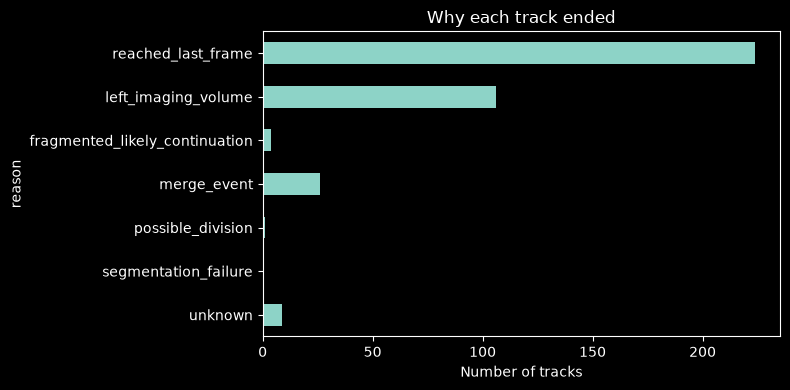

,track_id,last_frame,reason,candidate_track,daughter_a,daughter_b
0,48,0,unknown,NaN,NaN,NaN
1,94,0,left_imaging_volume,NaN,NaN,NaN
2,121,0,fragmented_likely_continuation,227.0,NaN,NaN
3,64,1,merge_event,NaN,NaN,NaN
4,67,1,merge_event,NaN,NaN,NaN
5,142,1,left_imaging_volume,NaN,NaN,NaN
6,193,1,left_imaging_volume,NaN,NaN,NaN
7,194,1,left_imaging_volume,NaN,NaN,NaN
8,200,1,unknown,NaN,NaN,NaN
9,214,1,left_imaging_volume,NaN,NaN,NaN


In [49]:
# ------------------------------------------------------------
# Quick visual of the breakdown
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
summary.plot(kind="barh")
plt.xlabel("Number of tracks")
plt.title("Why each track ended")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

track_endings.head(20)

## Save results

The original track IDs are preserved. Merge hypotheses, seed priors, and pending identity links are saved separately for local re-segmentation and later merge-aware track repair.


In [50]:
output_dir = (
    DATA_ROOT
    / "processed"
    / "stage_8_track_stitching"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print("Output directory:", output_dir)


Output directory: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_8_track_stitching


In [51]:
import json


# ------------------------------------------------------------
# Save detections
# ------------------------------------------------------------

detections_df = pd.concat(
    time_frames,
    keys=range(len(time_frames)),
    names=["frame"],
).reset_index(level=0)

detections_df.to_csv(
    output_dir / "detections.csv",
    index=False,
)


# ------------------------------------------------------------
# Save unchanged tracks
# ------------------------------------------------------------

tracks.to_csv(
    output_dir / "tracks.csv",
    index=False,
)


# ------------------------------------------------------------
# Save merge-aware diagnostic outputs
# ------------------------------------------------------------

segmentation_events.to_csv(
    output_dir / "segmentation_events.csv",
    index=False,
)

merge_seed_priors.to_csv(
    output_dir / "merge_seed_priors.csv",
    index=False,
)

merge_track_links.to_csv(
    output_dir / "merge_track_links.csv",
    index=False,
)


# ------------------------------------------------------------
# Save track termination classification
# ------------------------------------------------------------

track_endings.to_csv(
    output_dir / "track_endings.csv",
    index=False,
)


# ------------------------------------------------------------
# Save parameters
# ------------------------------------------------------------

metadata = {
    "legacy_gap_closing_enabled": ENABLE_LEGACY_GAP_CLOSING,
    "legacy_max_gap": MAX_GAP,
    "legacy_stitch_max_distance": STITCH_MAX_DISTANCE,
    "merge_detection_enabled": True,
    "voxel_size_zyx": VOXEL_SIZE_ZYX.tolist(),
    "merge_search_radius_um": MERGE_SEARCH_RADIUS_UM,
    "merge_position_scale_um": MERGE_POSITION_SCALE_UM,
    "merge_centroid_scale_um": MERGE_CENTROID_SCALE_UM,
    "merge_max_volume_relative_error": MERGE_MAX_VOLUME_REL_ERROR,
    "merge_max_intensity_sum_relative_error": (
        MERGE_MAX_INTENSITY_SUM_REL_ERROR
    ),
    "merge_min_score": MERGE_MIN_SCORE,
    "seed_radius_fraction": SEED_RADIUS_FRACTION,
    "minimum_seed_radius_um": MINIMUM_SEED_RADIUS_UM,
    "track_ids_rewritten": False,
}

with open(
    output_dir / "metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
    )


print(f"Saved Stage 9 results to: {output_dir}")
print("Files:")
for path in sorted(output_dir.iterdir()):
    print(" -", path.name)


Saved Stage 9 results to: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_8_track_stitching
Files:
 - detections.csv
 - merge_seed_priors.csv
 - merge_track_links.csv
 - metadata.json
 - segmentation_events.csv
 - track_endings.csv
 - tracks.csv
